# CS 415 Homework 2 Question 2: Building a Transformer for Spelling Correction

**Objective:** In this assignment, you will first create a dataset, then implement the attention mechanism to design and train an encoder-decoder model for spelling correction.

## Part 1: Setup and Imports

First, let's import all the necessary libraries and set up our device for training (GPU if available).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
import string
import math
from google.colab import files

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 2: Creating the Dataset
In this section, you will create a custom dataset using text of your choice. You need to provide a text file containing at least **100,000 characters** (around 60 pages of a standard book). We will then use a "corruptor" function to artificially introduce spelling mistakes, creating pairs of (bad, good) data for the model to learn from.

#### A training example looks like this:
* **Input:** A corrupted string (e.g., *"I am teh one woh knorks"*)
* **Target:** The original string (e.g., *"I am the one who knocks"*)

### **Your Task (2a):**
1.  Choose a text in **Modern English**. You can create this dataset by combining different texts. It can include parts of your favorite novel, a collection of technical papers, or even something you wrote in the past. Avoid texts with non-standard alphabets (e.g., emojis, foreign characters) to keep the vocabulary size manageable. A suggestion is downloading any text from https://sherlock-holm.es/ascii/, the larger the better, but you're free to pick your own text.
2.  Upload a .txt file containing your chosen text using the cell below.
3.  Make sure that it contains at least 100,000 characters so that your model has enough data to learn from. Note that a text with more than 5 million characters might be computationally infeasible.

> **Note:** The performance of your model will vary depending on the complexity and size of the text you choose. However, this won't be a problem since you will be graded on the correctness of your implementation rather than the final accuracy.

In [ ]:
# Run this cell to upload your file
print("--- Upload Check ---")
uploaded = files.upload()

if len(uploaded) > 0:
    # Get the first uploaded file
    filename = next(iter(uploaded))
    print(f"Reading from file: {filename}")
    raw_text = uploaded[filename].decode("utf-8")
else:
    print("No file uploaded. Using pasted text.")

# Text length check
assert len(raw_text) > 100000, f"Your text is too short ({len(raw_text)} chars). Please use at least 100,000 characters."
print(f"Raw Text Length: {len(raw_text)} characters")

--- Upload Check ---


Saving wordstext.txt to wordstext (2).txt
Reading from file: wordstext (2).txt
Raw Text Length: 159630 characters


Before we can train anything, we need to convert our raw string into integers.

Real-world data is messy. Your text might contain emojis, rare unicode symbols, or different types of whitespace. To keep our model simple, we will restrict the allowed characters to standard English characters.

In [ ]:
# Define the allowed characters (standard English letters + punctuation + numbers)

# We add a generic ' ' space to handle newlines and tabs simply.
ALLOWED_CHARS = set(string.ascii_letters + string.digits + string.punctuation + " ")

def clean_text(text):
    # 1. Replace newlines/tabs with spaces
    text = text.replace('\n', ' ').replace('\t', ' ')

    # 2. Filter out characters not in our allowed set
    cleaned = ''.join(c for c in text if c in ALLOWED_CHARS)

    # 3. Collapse multiple spaces into one
    cleaned = ' '.join(cleaned.split())
    return cleaned

# Clean the raw_text from the previous cell
clean_raw_text = clean_text(raw_text)

print(f"Original Length: {len(raw_text)}")
print(f"Cleaned Length:  {len(clean_raw_text)}")
print(f"First 100 chars: {clean_raw_text[:100]}")

Original Length: 159630
Cleaned Length:  142537
First 100 chars: THE COMPLETE SHERLOCK HOLMES Arthur Conan Doyle Table of contents A Study In Scarlet The Sign of the


Now we create the mappings between characters and integers. For example:
* char_to_idx: Maps 'a' to 1
* idx_to_char: Maps 1 to 'a'

We also need special tokens:
* PAD (0): Padding, used if we have sequences of different lengths (though in this assignment, we will use fixed windows).
* SOS (1): Start of Sequence.
* EOS (2): End of Sequence.

In [ ]:
# Create unique character list
chars = sorted(list(set(clean_raw_text)))

# Define Special Tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

# Add special tokens to the list
chars = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + chars

# Create Mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)

print(f"Vocabulary Size: {vocab_size}")
print(f"Sample Mappings: {list(char_to_idx.items())[:10]}")

Vocabulary Size: 76
Sample Mappings: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), (' ', 3), ('!', 4), ('"', 5), ("'", 6), ('(', 7), (')', 8), (',', 9)]


### **Your Task (2b):**
We now need to define the corruptor function.It should iterate through the input string and, with probability noise_prob, apply one of the following errors:
* Swap: Swap the current character with its neighbor. (e.g., "the" $\rightarrow$ "teh")
* Drop: Delete the character completely. (e.g., "table" $\rightarrow$ "tble"
* Add: Insert a random character from the vocabulary. (e.g., "apple" $\rightarrow$ "appxle")

In [ ]:
# corrupter function
def corrupt_text(text, noise_prob=0.1):
    """
    Args:
        text (str): The clean input string.
        noise_prob (float): Probability of a mutation occurring at each step.

    Return:
        str: The corrupted string.
    """
    vocab = list(set(text))
    corrupted = []
    i = 0

    while i < len(text):
        # decide whether or not to apply noise
        if random.random() < noise_prob:
            # Pick a random error type:
            #   1. Swap (if not at the very end)
            #   2. Drop (skip this char)
            #   3. Add (insert random char, then append current char)
            error_type = random.choice(['swap', 'drop', 'add'])

            # fill in the logic:
            if error_type == 'swap' and i < len(text) - 1:
                # Swap current char with the next one
                corrupted.append(text[i + 1])
                corrupted.append(text[i])
                i += 2

            elif error_type == 'drop':
                # Skip the current character (effectively deleting it)
                i += 1

            elif error_type == 'add':
                # Insert a random character, then keep the original
                corrupted.append(random.choice(vocab))
                corrupted.append(text[i])
                i += 1

            else:
                # Fallback: If we can't swap (end of string), just keep it
                corrupted.append(text[i])
                i += 1
        else:
            # No noise: Keep character as is
            corrupted.append(text[i])
            i += 1

    return "".join(corrupted)

# --- Verification ---
# Run this to verify your function works
test_str = "I am the one who knocks."  # Write any sentence here
print(f"Original:  {test_str}")
print(f"Corrupted: {corrupt_text(test_str, noise_prob=0.2)}")

Original:  I am the one who knocks.
Corrupted: oI m the noe who nocks.


### **Your Task (2c):**
Finally, we wrap this all into a PyTorch Dataset. This class handles the Sliding Window logic.

Instead of pre-generating a massive list of strings, we will use On-the-Fly Generation.

1. **\_\_getitem__** selects a window of text (e.g., 64 characters) from the clean text.

2. It calls the corrupt_text function on that window to generate the input.

3. It converts both the Input (Corrupted) and Target (Clean) into tensors of integers.

Crucial Detail: The Decoder needs a target_input (what it sees) and a target_output (what it predicts).

If target is "ABC", the Decoder input is <SOS> A B and the label is A B C <EOS>.

In [ ]:
# create the spellingdataset class
class SpellingDataset(Dataset):
    def __init__(self, text, char_to_idx, seq_len=64):
        self.text = text
        self.char_to_idx = char_to_idx
        self.idx_to_char = {v: k for k, v in char_to_idx.items()}
        self.seq_len = seq_len

    def __len__(self):
        # We can extract (Length - Seq_Len) possible windows
        return max(0, len(self.text) - self.seq_len)

    def __getitem__(self, idx):
        # Grab the clean window
        clean_window = self.text[idx : idx + self.seq_len]

        # Corrupt it to create the input
        # Note: We corrupt ONLY the input. The target must remain clean.
        corrupted_window = corrupt_text(clean_window)

        # Encode (String -> List of Integers)
        # We use a helper to safely look up characters
        def encode(s):
            return [self.char_to_idx.get(c, self.char_to_idx[PAD_TOKEN]) for c in s]

        x_enc = encode(corrupted_window)
        y_clean = encode(clean_window)

        # Pad/Truncate the integers (List[int] -> Fixed List[int])
        pad_idx = self.char_to_idx[PAD_TOKEN]

        def force_len(lst, length):
            if len(lst) > length:
                return lst[:length]
            elif len(lst) < length:
                return lst + [pad_idx] * (length - len(lst))
            return lst

        # Pass x_enc and y_clean through the newly defined force_len function
        x_enc = force_len(x_enc, self.seq_len)
        y_clean = force_len(y_clean, self.seq_len)

        return torch.tensor(x_enc, dtype=torch.long), torch.tensor(y_clean, dtype=torch.long)

# Test the Dataset
ds = SpellingDataset(clean_raw_text, char_to_idx, seq_len=40)
x, y = ds[0]
print("Input Tensor shape:", x.shape)
print("Target Tensor shape:", y.shape)
print("Input String:", "".join([idx_to_char[i.item()] for i in x]))
print("Target String:", "".join([idx_to_char[i.item()] for i in y]))

Input Tensor shape: torch.Size([40])
Target Tensor shape: torch.Size([40])
Input String: THE COMPETE SHERLOCKM HOLEME Arthur Cona
Target String: THE COMPLETE SHERLOCK HOLMES Arthur Cona


## Part 3: Creating The Attention Mechanism

This is the heart of the Transformer. Unlike RNNs, which process data sequentially, Attention allows the model to look at **all tokens at once** and decide which ones are important.

You will implement the core mathematical operation: **Scaled Dot-Product Attention**.

### The Math
The attention score is calculated using three vectors: **Query ($Q$)**, **Key ($K$)**, and **Value ($V$)**.
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

1.  **$QK^T$**: Measures similarity between Queries and Keys. If a Query matches a Key, the dot product is high.
2.  **$\sqrt{d_k}$**: A scaling factor where $d_k$ is the dimension of the keys and queries.
3.  **Softmax**: Converts scores into probabilities (weights) that sum to 1.
4.  **$V$**: The weighted sum of Values is the final output.

### **Your Task (3)**
1.  Implement the `scaled_dot_product_attention` function.
2.  Implement the `MultiHeadAttention` class. This class projects the input into multiple "heads" so the model can pay attention to different aspects of the text simultaneously (e.g., Head 1 focuses on grammar, Head 2 focuses on meaning).

In [ ]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Computes the scaled dot product attention.

    Args:
        query: Tensor of shape (batch_size, num_heads, seq_len, d_k)
        key:   Tensor of shape (batch_size, num_heads, seq_len, d_k)
        value: Tensor of shape (batch_size, num_heads, seq_len, d_k)
        mask:  Optional tensor (batch_size, 1, 1, seq_len) or broadcastable.
               Values should be 0 for mask out and 1 for keep.


    Returns:
        output: Weighted sum of values
        attn_probs: The attention weights (for visualization)
    """
    d_k = query.size(-1)

    # 1. Calculate Dot Product: (Batch, Heads, Seq_Q, Dim) x (Batch, Heads, Dim, Seq_K)
    # Result shape: (Batch, Heads, Seq_Q, Seq_K)
    scores = torch.matmul(query, key.transpose(-2, -1))

    # 2. Scale scores
    scores = scores / math.sqrt(d_k)

    # 3. Apply Mask (if provided)
    if mask is not None:
        # Assuming mask: 1 = keep, 0 = mask (ignore)
        # In theory we set masked positions to negative infinity (so that they become 0 after Softmax) but in practice a large negative value like -1e9 suffices
        scores = scores.masked_fill(mask == 0, -1e9)

    # 4. Softmax
    attn_probs = F.softmax(scores, dim=-1)

    # 5. Multiply by Value
    # (Batch, Heads, Seq_Q, Seq_K) x (Batch, Heads, Seq_K, Dim) -> (Batch, Heads, Seq_Q, Dim)
    output = torch.matmul(attn_probs, value)

    return output, attn_probs


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections for Q, K, V
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # 1. Linear Projection & Split Heads
        # We reshape to (Batch, Seq_Len, Num_Heads, d_k) then transpose to (Batch, Num_Heads, Seq_Len, d_k)
        # This puts the "Head" dimension before the Sequence dimension, allowing for parallel computation.

        q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Apply Scaled Dot Product Attention
        # Output shape: (Batch, Num_Heads, Seq_Len, d_k)
        x, attn_probs = scaled_dot_product_attention(q, k, v, mask=mask)

        # 3. Concatenate Heads
        # Transpose back: (Batch, Seq_Len, Num_Heads, d_k)
        x = x.transpose(1, 2).contiguous()
        # Flatten: (Batch, Seq_Len, d_model)
        x = x.view(batch_size, -1, self.d_model)

        # 4. Final Linear Projection
        return self.w_o(x), attn_probs

# --- Verification ---
# Create random tensors
d_model = 64
heads = 4
seq_len = 10
batch = 2

mha = MultiHeadAttention(d_model, heads)
x_test = torch.randn(batch, seq_len, d_model)

# Self-attention: Q, K, V are all the same input x
output, probs = mha(x_test, x_test, x_test)

print(f"Input Shape:  {x_test.shape}")
print(f"Output Shape: {output.shape}") # Should be [2, 10, 64]
print(f"Attn Shape:   {probs.shape}")  # Should be [2, 4, 10, 10]

Input Shape:  torch.Size([2, 10, 64])
Output Shape: torch.Size([2, 10, 64])
Attn Shape:   torch.Size([2, 4, 10, 10])


## Part 4: Creating the Transformer Model

Now we assemble the pieces. A Transformer is not just Attention; it is a stack of layers that refine the representation step-by-step.

### 1. Positional Encoding
Since the Transformer reads all tokens at once, it has no sense of order. "Dog bites man" looks the same as "Man bites dog" to the self-attention mechanism.
To fix this, we inject **Positional Encodings**—patterns added to the embeddings to tell the model *where* each token is in the sentence.

### 2. The Architecture
We are building a **Seq2Seq** model:
* **Encoder:** Reads the corrupted input. It consists of `N` layers. Each layer has **Self-Attention** followed by a **Feed-Forward Network**.
* **Decoder:** Generates the clean output. It is trickier. Each layer has:
    1.  **Masked Self-Attention:** Looks at previous tokens it generated.
    2.  **Cross-Attention:** Looks at the *Encoder's* output (Source) to extract relevant information.
    3.  **Feed-Forward Network.**



### **Your Task (4):**
1.  Implement the `EncoderLayer` and `DecoderLayer`. Pay close attention to the **Cross-Attention** block in the Decoder: The *Queries* come from the Decoder, but the *Keys and Values* come from the Encoder.
2.  Assemble the final `SpellingTransformer` class.

In [ ]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # matrix of [max_len, d_model] representing positional patterns
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as a buffer (not a learnable parameter, but part of state_dict)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [Batch, Seq_Len, d_model]
        x = x + self.pe[:, :x.size(1)]
        return x

# Feed Forward Network
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)  #
        self.dropout = nn.Dropout(dropout)  #

    def forward(self, x, mask):
        # 1. Self Attention + Add & Norm
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # 2. Feed Forward + Add & Norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x

# Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, trg_mask):
        # 1. Masked Self Attention (Decoder looks at itself)
        # trg_mask ensures we don't cheat by looking ahead
        attn_out, _ = self.self_attn(x, x, x, trg_mask)
        x = self.norm1(x + self.dropout(attn_out))

        # 2. Cross Attention (Decoder looks at Encoder)
        # Query = Decoder (x), Key/Value = Encoder Output
        # src_mask ensures we don't pay attention to padding in the source
        attn_out, attention_weights = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_out))

        # 3. Feed Forward
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))

        return x, attention_weights

In [ ]:
# The Full Transformer
class SpellingTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def make_src_mask(self, src):
        # Mask PAD tokens (assuming PAD index is 0)
        # Shape: [Batch, 1, 1, Src_Len]
        return (src != 0).unsqueeze(1).unsqueeze(2)

    def make_trg_mask(self, trg):
        # Mask PAD tokens AND future tokens (Causal Mask)
        N, trg_len = trg.shape
        # Pad mask
        pad_mask = (trg != 0).unsqueeze(1).unsqueeze(2)
        # Causal mask (Lower Triangular)
        sub_mask = torch.tril(torch.ones((trg_len, trg_len), device=trg.device)).bool()

        return pad_mask & sub_mask

    def forward(self, src, trg):
        # src: [Batch, Src_Len], trg: [Batch, Trg_Len]

        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)

        # Encoder
        enc_out = self.dropout(self.pos_encoder(self.embedding(src)))
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        # Decoder
        dec_out = self.dropout(self.pos_encoder(self.embedding(trg)))
        for layer in self.decoder_layers:
            dec_out, attention_weights = layer(dec_out, enc_out, src_mask, trg_mask)

        output = self.fc_out(dec_out)
        return output, attention_weights

## Part 5: Training

Now that our model is defined, we can finally instantiate and train it. Feel free to change the hyperparameter setup below according to your preferences/resources.

During training, we use teacher forcing: instead of giving the decoder its own previous predictions, we feed it the gold target sequence shifted by one position.

* Input: "I lovv dpee lerning"
* Target: "I love deep learning"

To train the model to output **"Learning"**, the decoder is run with inputs [START, "I", "love", "deep"] regardless of the models previous predictions.


### **Your Task (5):**
Prepare decoder_input and target_label by completing the make_decoder_io function, using teacher forcing.

In [ ]:
# Hyperparameters
D_MODEL = 256
NUM_HEADS = 8
NUM_LAYERS = 4
D_FF = 512
DROPOUT = 0.1
LR = 0.0001
BATCH_SIZE = 32
EPOCHS = 3 #adjust to 3 since it is too slow to train.
SEQ_LEN = 40

# Dataset & DataLoader
# We use the clean_raw_text and char_to_idx mapping from Part 2
dataset = SpellingDataset(clean_raw_text, char_to_idx, seq_len=SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Model Initialization
model = SpellingTransformer(
    vocab_size=vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(device)

# Optimizer & Loss
optimizer = optim.Adam(model.parameters(), lr=LR)

# Ignore the padding index when calculating the loss
criterion = nn.CrossEntropyLoss(ignore_index=char_to_idx[PAD_TOKEN])

print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")

Model has 5,310,540 parameters


In [ ]:
def make_decoder_io(trg_raw, SOS_IDX, EOS_IDX, device):
    """
    Prepares the input and target tensors for the Decoder using Teacher Forcing.

    Args:
        trg_raw: Clean ground truth label indices
        SOS_IDX
        EOS_IDX
    Returns:
        decoder_input: Includes SOS, excludes EOS.
        target_label: Excludes SOS, includes EOS.
    """
    batch_size, seq_len = trg_raw.shape

    # Create batches of SOS and EOS tokens
    # Shape: [Batch_Size, 1]
    sos = torch.full((batch_size, 1), SOS_IDX, device=device, dtype=torch.long)
    eos = torch.full((batch_size, 1), EOS_IDX, device=device, dtype=torch.long)

    # Construct Decoder Input (Teacher Forcing)
    # We want: [SOS] + [Sequence]
    decoder_input = torch.cat([sos, trg_raw[:, :-1].to(device)], dim=1)

    # Construct Target Label
    # We want: [Sequence] + [EOS]
    target_label = torch.cat([trg_raw[:, 1:].to(device), eos], dim=1)

    return decoder_input, target_label

In [ ]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0

    for i, (src, trg_raw) in enumerate(dataloader):
        src = src.to(device)
        trg_raw = trg_raw.to(device)

        # Prepare Input/Output for Decoder
        decoder_input, target_label = make_decoder_io(
            trg_raw,
            char_to_idx[SOS_TOKEN],
            char_to_idx[EOS_TOKEN],
            device
        )

        optimizer.zero_grad()

        # output shape: [Batch, Seq_Len + 1, Vocab_Size]
        output, _ = model(src, decoder_input)

        # CrossEntropy expects: (N, C) and (N)
        output_dim = output.shape[-1]

        # Flatten output to [Batch * Seq_Len, Vocab_Size]
        output = output.view(-1, output_dim)
        # Flatten label to [Batch * Seq_Len]
        target_label = target_label.view(-1)

        # Calculate loss and update
        loss = criterion(output, target_label)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if i % 100 == 0:
            print(f"Batch {i}/{len(dataloader)} Loss: {loss.item():.4f}")

    return epoch_loss / len(dataloader)

# --- Run Training ---
for epoch in range(EPOCHS):
    loss = train_epoch(model, dataloader, optimizer, criterion, device)
    print(f"Epoch {epoch+1} | Loss: {loss:.4f}")

Batch 0/4454 Loss: 4.5271
Batch 100/4454 Loss: 2.8169
Batch 200/4454 Loss: 2.6436
Batch 300/4454 Loss: 2.1875
Batch 400/4454 Loss: 1.7921
Batch 500/4454 Loss: 1.5580
Batch 600/4454 Loss: 1.4580
Batch 700/4454 Loss: 1.2758
Batch 800/4454 Loss: 1.2407
Batch 900/4454 Loss: 1.2024
Batch 1000/4454 Loss: 1.1637
Batch 1100/4454 Loss: 1.0131
Batch 1200/4454 Loss: 1.0609
Batch 1300/4454 Loss: 1.0311
Batch 1400/4454 Loss: 0.9256
Batch 1500/4454 Loss: 0.9585
Batch 1600/4454 Loss: 0.9056
Batch 1700/4454 Loss: 0.8293
Batch 1800/4454 Loss: 0.7921
Batch 1900/4454 Loss: 0.7375
Batch 2000/4454 Loss: 0.7748
Batch 2100/4454 Loss: 0.7912
Batch 2200/4454 Loss: 0.7803
Batch 2300/4454 Loss: 0.6501
Batch 2400/4454 Loss: 0.7197
Batch 2500/4454 Loss: 0.7466
Batch 2600/4454 Loss: 0.7187
Batch 2700/4454 Loss: 0.6812
Batch 2800/4454 Loss: 0.6775
Batch 2900/4454 Loss: 0.7672
Batch 3000/4454 Loss: 0.6373
Batch 3100/4454 Loss: 0.6560
Batch 3200/4454 Loss: 0.6501
Batch 3300/4454 Loss: 0.5834
Batch 3400/4454 Loss: 0.66

## Part 6: Inference and Evaluation

We need a decoding mechanism to convert logits into actual token predictions. Greedy decoding does this by, at each time step, choosing the most likely token and feeding it back as the next input. Finally we'll see our model in action on some test sentences.

### Your Task (6):

Complete the function below to implement greedy decoding.

In [ ]:
def greedy_decode(sentence, model, device, max_len=50):
    model.eval()

    # Clean and Encode the Input
    clean = clean_text(sentence)
    indices = [char_to_idx.get(c, char_to_idx[PAD_TOKEN]) for c in clean]
    src_tensor = torch.tensor(indices).unsqueeze(0).to(device)

    # Initialize Decoder Input with <SOS>
    trg_indices = [char_to_idx[SOS_TOKEN]]

    with torch.no_grad():
        for i in range(max_len):
            # Convert list to tensor
            trg_tensor = torch.tensor(trg_indices).unsqueeze(0).to(device)

            # Forward pass
            # We pass the current target sequence
            output, attn_weights = model(src_tensor, trg_tensor)

            # Get the last token prediction
            # output shape: [1, Seq_Len, Vocab_Size]
            last_token_logits = output[:, -1, :]
            pred_token_idx = torch.argmax(last_token_logits, dim=-1).item()

            if pred_token_idx == char_to_idx[EOS_TOKEN]:
                break

            # Append to sequence
            trg_indices.append(pred_token_idx)

    # Convert to string
    corrected = "".join([idx_to_char[idx] for idx in trg_indices[1:]])
    return corrected, attn_weights

In [ ]:
# You can also write your own test sentences containing typos below
test_sentences = [
    "I finf yor lack of fath disturbin.",
    "Fear is the path to the dak side, fesr leds to anget.",
    "The man who pases the sentense shold swing the sord.",
    "A lion does not concern himswlf with the opinon of sheep.",
    "I solemly swer that I am up to no god.",
    "It does not do to dwel on drems and forgrt to lve.",
    "All we have to declde is wat to do witg the tme that is given us.",
    "Even the smalest person can chenge the course of the futur."
]

print(f"{'Input (Typo)':<60} | {'Model Prediction':<60}")
print("-" * 125)

model.eval()

for text in test_sentences:
    prediction, _ = greedy_decode(text, model, device, max_len=100)

    print(f"{text:<60} | {prediction:<60}")

Input (Typo)                                                 | Model Prediction                                            
-----------------------------------------------------------------------------------------------------------------------------
I finf yor lack of fath disturbin.                           |   i i o o akako frffathddit trbrbiiiie.                     
Fear is the path to the dak side, fesr leds to anget.        | ea steh eptahttttotthdak i,dfrs nrlc et                     
The man who pases the sentense shold swing the sord.         | h a a hwpaest h h esnetes hrlds i hnsml                     
A lion does not concern himswlf with the opinon of sheep.    | lin odsnsntococncrnrhmswfwihw i h oe oh                     
I solemly swer that I am up to no god.                       |   oemyey ewr hta ta     mdpto nt ogdn."                     
It does not do to dwel on drems and forgrt to lve.           | tde o otdotototdodwlondrm adsadfrgt o o                     
All we

## Part 7: Conceptual Questions

Briefly answer the following questions:

1. In the decoder's cross-attention block, where do the queries, keys, and the values come from?
2. When you run a well-trained model on a sentence with no errors and visualize the attention weights, you should observe a diagonal line in at least one of the heads. You can try this by running the cell below. What does this diagonal line represent in terms of the model's behaviour?

1. In the decoder’s cross-attention block, the queries come from the decoder’s current hidden states.
the keys and values come from the encoder output representations of the source. In other words:
Q = decoder states,
K = encoder states,
V = encoder states.


2. A diagonal line in an attention heatmap means the model is mostly doing position-aligned copying: at target position *t*; it puts the highest attention weight on source position *t*. For a clean sentence, this indicates the model has learned an identity behavior where each output character is produced by looking at the corresponding input character, so attention concentrates along the one-to-one alignment between input and output characters. So to explain it as simplifed: It reflects a near one-to-one alignment between the input and output sequences, meaning the model typically looks at the same-index source character when predicting each target character. In other words, when no correction is needed, the model behaves like a copier, using attention primarily to confirm and reproduce the original text rather than to rearrange or infer missing characters.

Input:  The quick brown fox jumps over the lazy dog.
Output: h ukc rcbrwno o o upsvr vrtete ayo o ad


/tmp/ipython-input-998185209.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(sentence), rotation=90)
/tmp/ipython-input-998185209.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + list(predicted_text))
/tmp/ipython-input-998185209.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(sentence), rotation=90)
/tmp/ipython-input-998185209.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + list(predicted_text))
/tmp/ipython-input-998185209.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set

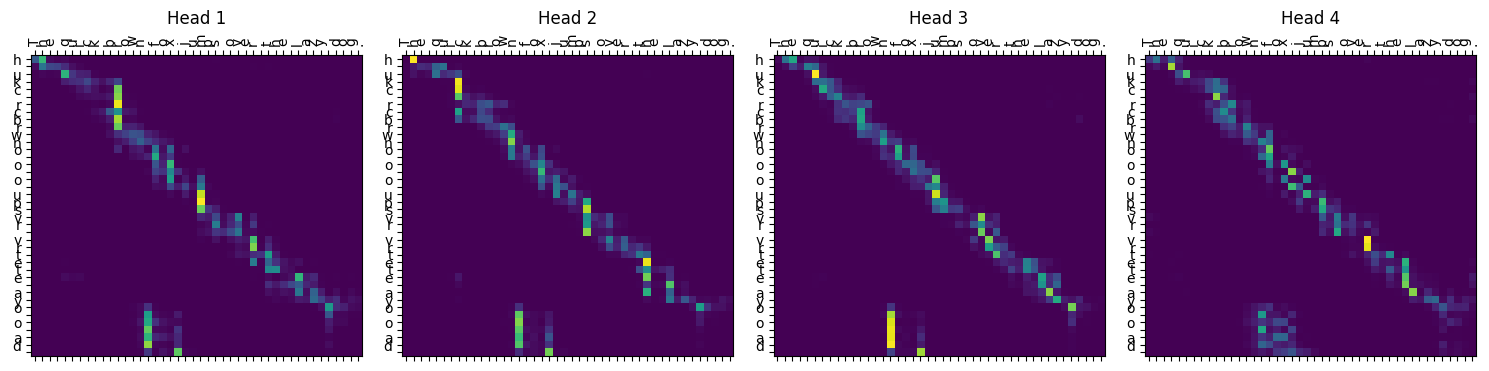

In [ ]:
def plot_attention(sentence, predicted_text, attention, n_heads=4):
    attention = attention.squeeze(0).cpu().detach().numpy()

    fig = plt.figure(figsize=(15, 8))

    for h in range(n_heads):
        ax = fig.add_subplot(1, n_heads, h+1)

        cax = ax.matshow(attention[h], cmap='viridis')

        ax.set_xticklabels([''] + list(sentence), rotation=90)
        ax.set_yticklabels([''] + list(predicted_text))

        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

        ax.set_title(f'Head {h+1}')

    plt.tight_layout()
    plt.show()

# --- Run Visualization on Clean Text ---
test_text = "The quick brown fox jumps over the lazy dog."

prediction, attn_weights = greedy_decode(test_text, model, device)

print(f"Input:  {test_text}")
print(f"Output: {prediction}")

plot_attention(test_text, prediction, attn_weights, n_heads=4)